# 10 · Credits, estimates, quotas and typed errors

**Use case.** Before wiring Langsat into automation you want to know what things cost, how much is left, and that a script can branch on *what* went wrong — without parsing English.

**What you will learn**
1. Balance, usage over time (as a chart) and quota
2. `estimates()` across every project of this series — one table
3. The training estimate with its knobs (`max_mode`, `fan_out_workers`)
4. The error catalogue in action: `NotFound`, `Invalid`, `NeedsUserSession` — and what the others mean
5. Least privilege: what the key may do

**What this costs.** nothing — every call here is a read.

> Every cell below ran for real against `api.langsat.ai` — the outputs are what the API returned. Re-running is safe:
> projects are found by name and reused, and a finished model is not retrained.

In [1]:
import sys, json
sys.path.insert(0, "..")
from _common import connect, get_or_create_project, print_schema, train_or_reuse, credits_used, save_metrics, show, fig, metrics_table, project_models
from langsat import viz
import pandas as pd

ls = connect()

signed in as team@langsat.ai · tier team · key 'TEST-SDK-4' with 20 scopes


In [2]:
d = ls.credits.dashboard()
pool = d.get("org_pool") or {}
print("plan:", d.get("tier"), "· personal balance:", d.get("balance_credits"), "· team pool:", pool.get("balance_credits"), "· used this month:", pool.get("credits_used_this_month"))
q = ls.credits.quota_status()
print("AI quota today:", q["usage"], "· compute cap today (USD):", q["compute"].get("cap_today_usd"), "· used:", q["compute"].get("used_today_usd"))

plan: team · personal balance: 0 · team pool: 999962432 · used this month: 42426


AI quota today: {'pct_today': 1, 'pct_month': 0} · compute cap today (USD): 3.333 · used: 0.0064


The ledger. `dashboard()` carries the latest transactions of the account that pays (the team pool here); `usage()` is the public-API lens (predict / forecast calls by day and by model). Below: what this series of notebooks spent, grouped by what it was for.

,created_at,tx_type,amount,description
0,2026-09-16 03:06:02.250046+00:00,debit,-250,Batch predict (API · 5 items)
1,2026-09-16 03:06:01.915443+00:00,debit,-50,Ranked top-5 (API)
2,2026-09-16 03:06:01.587316+00:00,refund,50,Refund for failed request (50 credits)
3,2026-09-16 03:06:00.480411+00:00,debit,-50,Predict (API)
4,2026-09-16 03:05:57.657549+00:00,debit,-50,Predict (API)
5,2026-09-16 03:05:12.004444+00:00,debit,-152,Forecast (API · multi-series)
6,2026-09-16 03:05:09.309408+00:00,debit,-76,Forecast (API)
7,2026-09-16 03:04:57.322671+00:00,debit,-76,Forecast (API)


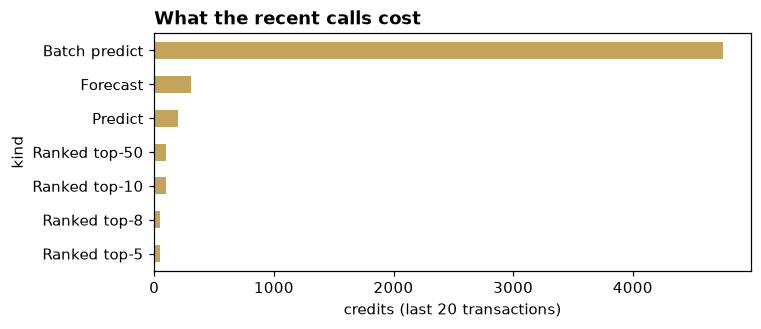

public-API lens, 30 days: {'total_calls': 0, 'total_credits': 0, 'training_jobs': 0}


In [3]:
tx = pd.DataFrame(d["recent_transactions"])
tx["created_at"] = pd.to_datetime(tx["created_at"]); tx["kind"] = tx["description"].str.replace(r" \(.*\)| ·.*", "", regex=True).str[:32]
display(tx[["created_at", "tx_type", "amount", "description"]].head(8))
spent = (-tx[tx["tx_type"] == "debit"].groupby("kind")["amount"].sum()).sort_values()
import matplotlib.pyplot as plt
f, ax = plt.subplots(figsize=(7, 2.8)); spent.plot(kind="barh", ax=ax, color="#c4a35a"); ax.set_xlabel("credits (last 20 transactions)")
ax.set_title("What the recent calls cost", loc="left", fontweight="bold"); fig(f)
api = ls.credits.usage(days=30)
print("public-API lens, 30 days:", {k: api.get(k) for k in ("total_calls", "total_credits", "training_jobs")})

## What would it cost?

`estimates()` is one read per project: clean, refresh, train (instance and floor), ask, predict, serving. Nothing is reserved or charged.

In [4]:
names = ["explore", "rating-regression", "rating-classes", "verified", "product-clusters", "review-anomalies"]
rows = []
for slug in names:
    pr = next((x for x in ls.projects.list() if x.name == f"amazon-reviews-{slug}"), None)
    if pr is None: continue
    e = pr.estimates()
    rows.append({"project": slug, "type": pr.data.get("project_type"), "clean_cr": e["clean"]["credits"], "clean_lane": e["clean"]["lane"],
                 "train_instance": (e.get("train") or {}).get("instance_type"), "train_min_floor": (e.get("train") or {}).get("suggested_minutes"),
                 "predict_cr": e["predict"]["credits_per_call"], "serving_cr_per_h": (e.get("serving") or {}).get("spot", {}).get("credits_per_hour")})
pd.DataFrame(rows)

,project,type,clean_cr,clean_lane,train_instance,train_min_floor,predict_cr,serving_cr_per_h
0,explore,data_analysis,0,lambda,NaN,NaN,50,922
1,rating-regression,data_science,0,lambda,g4dn.2xlarge,71.0,50,922
2,rating-classes,data_science,0,lambda,g4dn.2xlarge,71.0,50,922
3,verified,data_science,0,lambda,g4dn.2xlarge,71.0,50,922
4,product-clusters,data_science,0,lambda,g4dn.2xlarge,67.0,50,922
5,review-anomalies,data_science,0,lambda,g4dn.2xlarge,71.0,50,922


The training estimate accepts the run's knobs. `max_mode` (the architecture bake-off) and `fan_out_workers` (embedding helpers) change the reservation — compare the three rows.

In [5]:
p = next(x for x in ls.projects.list() if x.name == "amazon-reviews-rating-regression")
est = []
for kw in ({}, {"fan_out_workers": 2}, {"max_mode": True}):
    r = ls.credits.estimate_training(estimated_minutes=71, max_training_min=71, project_id=p.id, **kw)
    est.append({"options": kw or "default", "instance": r["instance_type"], "cr_per_min": r["cr_per_min"], "reserved_credits": r["max_cost"],
                "fan_out_helpers": r["fan_out_helpers"], "benchmark_workers": r["benchmark_workers"]})
pd.DataFrame(est)

,options,instance,cr_per_min,reserved_credits,fan_out_helpers,benchmark_workers
0,default,g4dn.2xlarge,133,9443,0,0
1,{'fan_out_workers': 2},g4dn.2xlarge,133,10931,1,0
2,{'max_mode': True},g4dn.2xlarge,133,9443,0,0


## Errors you can branch on

Every 4xx carries `X-Error-Code`; the SDK raises a typed exception with `.status`, `.code`, `.message`, `.detail`.

In [6]:
from langsat import errors
explore = next(x for x in ls.projects.list() if x.name == "amazon-reviews-explore")
try:
    ls.projects.get("00000000-0000-0000-0000-000000000000")
except errors.NotFound as e:
    print("NotFound         ·", e.status, e.code, "·", e.message)
try:
    ls.predict.forecast(project_id=explore.id, target="rating", window="fortnight", length=3)
except errors.Invalid as e:                               # 422: the request shape — detail names the field
    bad = e.detail[0] if isinstance(e.detail, list) and e.detail else e.detail
    print("Invalid          ·", e.status, "·", (bad.get("loc"), bad.get("msg")) if isinstance(bad, dict) else bad)
try:
    ls.request("GET", "/settings")                        # billing, settings, key management: a signed-in person only
except errors.NeedsUserSession as e:
    print("NeedsUserSession ·", e.status, e.code, "·", str(e.message)[:90])
print("MissingScope     · 403 missing_scope — a key without the scope a route needs (e.scope says which); this key carries all 20, so nothing here can trigger it")
print("ProjectBusy      · 409 project_busy — a second clean / train while one runs; Retry-After tells a script how long to wait (`wait_if_busy=` on the SDK call does it for you)")
print("InsufficientCredits · 402 · QuotaExceeded · 429 quota_exhausted · RateLimited · 429 rate_limited (retried automatically) · RowCapExceeded · 422 row_cap_exceeded")

NotFound         · 404 not_found · Project not found


Invalid          · 422 · (['body', 'window_type'], "Input should be 'minute', 'hour', 'day', 'week', 'month' or 'year'")
NeedsUserSession · 403 needs_user_session · This action is only available to a signed-in user, not to an API key.
MissingScope     · 403 missing_scope — a key without the scope a route needs (e.scope says which); this key carries all 20, so nothing here can trigger it
ProjectBusy      · 409 project_busy — a second clean / train while one runs; Retry-After tells a script how long to wait (`wait_if_busy=` on the SDK call does it for you)
InsufficientCredits · 402 · QuotaExceeded · 429 quota_exhausted · RateLimited · 429 rate_limited (retried automatically) · RowCapExceeded · 422 row_cap_exceeded


In [7]:
me = ls.me(); key = me["api_key"]
print("key:", key["name"], "·", len(key["scopes"]), "scopes:", key["scopes"])
print("projects allow-list:", key["project_ids"] or "all", "· expires:", key["expires_at"])
print("\nA key minted with only projects:read + data:read would get MissingScope (403, scope='projects:write') on projects.create(...) —")
print("mint keys with the smallest set a script needs: Settings → API keys → Permissions.")

key: TEST-SDK-4 · 20 scopes: ['chat', 'credits:read', 'dashboards:read', 'dashboards:write', 'data:read', 'data:write', 'hosting:write', 'inference:read', 'keys:read', 'model:read', 'monitoring:read', 'monitoring:write', 'predict', 'projects:read', 'projects:write', 'sources:write', 'teams:read', 'train', 'webhooks:read', 'webhooks:write']
projects allow-list: all · expires: 2026-10-15T12:37:35.791960+00:00

A key minted with only projects:read + data:read would get MissingScope (403, scope='projects:write') on projects.create(...) —
mint keys with the smallest set a script needs: Settings → API keys → Permissions.


In [8]:
save_metrics(".", {"notebook": "10_credits_estimates_and_errors", "task": "credits, estimates, typed errors", "model": "—",
                   "headline": {"plan": d.get("tier"), "scopes_on_key": len(key["scopes"]), "projects_estimated": len(rows),
                                "errors_demonstrated": ["NotFound", "Invalid", "NeedsUserSession"]}})

wrote results/metrics.json


PosixPath('results/metrics.json')

## Where to go next

- [11 · Fine-tune](../11_finetune/) and [12 · Training options](../12_training_options/) — the two notebooks that train again